In [1]:
import datajoint as dj

dj.config.load('/Users/neurozmar/Secrets/dj_local_conf_NDNF_behavior_HUN-REN_cloud.json')#dj_local_conf_NDNF_behavior_KOKI.json #dj_local_conf_NDNF_behavior_HUN
dj.conn() 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cv2
import os
import subprocess
import tempfile
import shutil

from ndnf_pipeline import experiment, videography

matplotlib.rc('font', size=14)

/Users/neurozmar/Scripts/NDNF-behavior/.venv/lib/python3.13/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-06-14 21:32:13,470][INFO]: DataJoint is configured from /Users/neurozmar/Secrets/dj_local_conf_NDNF_behavior_HUN-REN_cloud.json
[2026-06-14 21:32:13,530][INFO]: DataJoint 0.14.6 connected to rozmar@datajoint.ndnf.koki.hun-ren.hu:3306


## Parameters

In [8]:
subject_id      = 'human_10'
session         = 0
block           = 1
trial_start     = 0     # block-relative: 0 = first trial of block
trial_end       = 1
camera_name     = 'FrontCamera'

tail_s          = 100     # seconds of force tail to show per frame
force_axis_limit = 110.0  # (g) symmetric axis limits for both force plots
output_path     = '/Users/neurozmar/Data/temp/trial_video.mp4'
video_fps       = 20    # output video framerate

lang            = 'en'  # 'en' or 'hu'

## Load data from DataJoint

In [9]:
key = {'subject_id': subject_id, 'session': session}

# --- trials ---
block_trials  = np.sort((experiment.BehaviorTrial() & key & {'block': block}).fetch('trial'))
trials_needed = block_trials[trial_start : trial_end + 1]
print(f'Trials (session-absolute): {trials_needed}')

# --- force LUT and axis info from TaskSettings ---
task_setting_id = (experiment.Block() & key & {'block': block}).fetch1('task_setting_id')
target_force_lut = (experiment.TaskSettings() & key & {'task_setting_id': task_setting_id}).fetch1('target_force_lut')

force_axes = (experiment.TaskSettings.ForceAxis() & key & {'task_setting_id': task_setting_id}
              ).fetch('force_axis_idx', 'target_force_axes', 'force_direction', order_by='force_axis_idx')
force_axes_arrays = {idx: axes for idx, axes, _ in zip(*force_axes)}
force_directions  = {idx: d    for idx, _, d  in zip(*force_axes)}
# extent for imshow: [x_min, x_max, y_min, y_max]
lut_extent = [force_axes_arrays[0].min(), force_axes_arrays[0].max(),
              force_axes_arrays[1].min(), force_axes_arrays[1].max()]

# --- concatenate force, lickport, reward data (session-relative time) ---
all_force_t, all_force_0, all_force_1 = [], [], []
all_reward_t = []
all_lickport_t, all_lickport_pos = [], []
trial_start_times = {}

for trial in trials_needed:
    t_start = float((experiment.SessionTrial() & key & {'trial': trial}).fetch1('trial_start_time'))
    trial_start_times[trial] = t_start

    ft = (experiment.TrialForceTrace()                & key & {'trial': trial}).fetch1('force_trace_time')
    f0 = (experiment.TrialForceTrace.TrialForceAxis() & key & {'trial': trial, 'force_axis_idx': 0}).fetch1('force_trace_value')
    f1 = (experiment.TrialForceTrace.TrialForceAxis() & key & {'trial': trial, 'force_axis_idx': 1}).fetch1('force_trace_value')
    all_force_t.extend(ft + t_start)
    all_force_0.extend(f0)
    all_force_1.extend(f1)

    rewards = (experiment.TrialEvent() & key & {'trial': trial, 'trial_event_type': 'reward'}).fetch('trial_event_time')
    all_reward_t.extend(rewards + t_start)

    lp_t, lp_pos = (experiment.TrialRewardPortPosition() & key & {'trial': trial}
                    ).fetch1('reward_port_position_time', 'reward_port_position_values')
    all_lickport_t.extend(lp_t + t_start)
    all_lickport_pos.extend(lp_pos)

all_force_t       = np.array(all_force_t)
all_force_0       = np.array(all_force_0)
all_force_1       = np.array(all_force_1)
all_reward_t      = np.array(all_reward_t)
all_lickport_t    = np.array(all_lickport_t)
all_lickport_pos  = np.array(all_lickport_pos)

# normalize feedback to 0-1
lp_shifted        = all_lickport_pos - np.min(all_lickport_pos)
all_lickport_norm = lp_shifted / np.max(np.abs(lp_shifted))

# --- language labels ---
_labels = {
    'en': dict(time='Time (s)', feedback='Feedback',
               fb_start='start', fb_target='target',
               force_x=f'{force_directions.get(0,"Axis 0")} force (g)',
               force_y=f'{force_directions.get(1,"Axis 1")} force (g)',
               lbl_target='Target', lbl_current='Current'),
    'hu': dict(time='Idő (mp)', feedback='Visszajelzés',
               fb_start='start', fb_target='cél',
               force_x=f'{force_directions.get(0,"Axis 0")} erő (g)',
               force_y=f'{force_directions.get(1,"Axis 1")} erő (g)',
               lbl_target='Cél', lbl_current='Aktuális'),
}
lbl = _labels[lang]

# --- video: collect frame times ---
video_file_path    = None
frame_session_times = []
global_start_frame = None
global_end_frame   = None

for trial in trials_needed:
    tv      = (videography.TrialVideo() & key & {'device': camera_name, 'trial': trial}).fetch1()
    t_start = trial_start_times[trial]
    frame_session_times.extend(tv['trial_frame_times'] + t_start)
    if global_start_frame is None:
        global_start_frame = tv['trial_start_frame']
        vf = (videography.VideoFile() & key & {'device': camera_name,
                                               'video_file_idx': tv['video_file_idx']}).fetch1()
        video_file_path = os.path.join(dj.config['path.raw_data'], vf['file_path'])
    global_end_frame = tv['trial_end_frame']

frame_session_times = np.array(frame_session_times)
t_video_start = float(trial_start_times[trials_needed[0]])
t_video_end   = float((experiment.SessionTrial() & key & {'trial': int(trials_needed[-1])}).fetch1('trial_end_time'))

print(f'Video file: {video_file_path}')
print(f'Frames: {global_start_frame} – {global_end_frame}  ({global_end_frame - global_start_frame + 1} frames)')

Trials (session-absolute): [26 27]
Video file: /Users/neurozmar/Data/behavior/Behavior_0/human_10/human_10_2026-05-28T074730.486034Z/behavior-videos/FrontCamera/video.mkv
Frames: 24 – 1980  (1957 frames)


## Preview — last frame

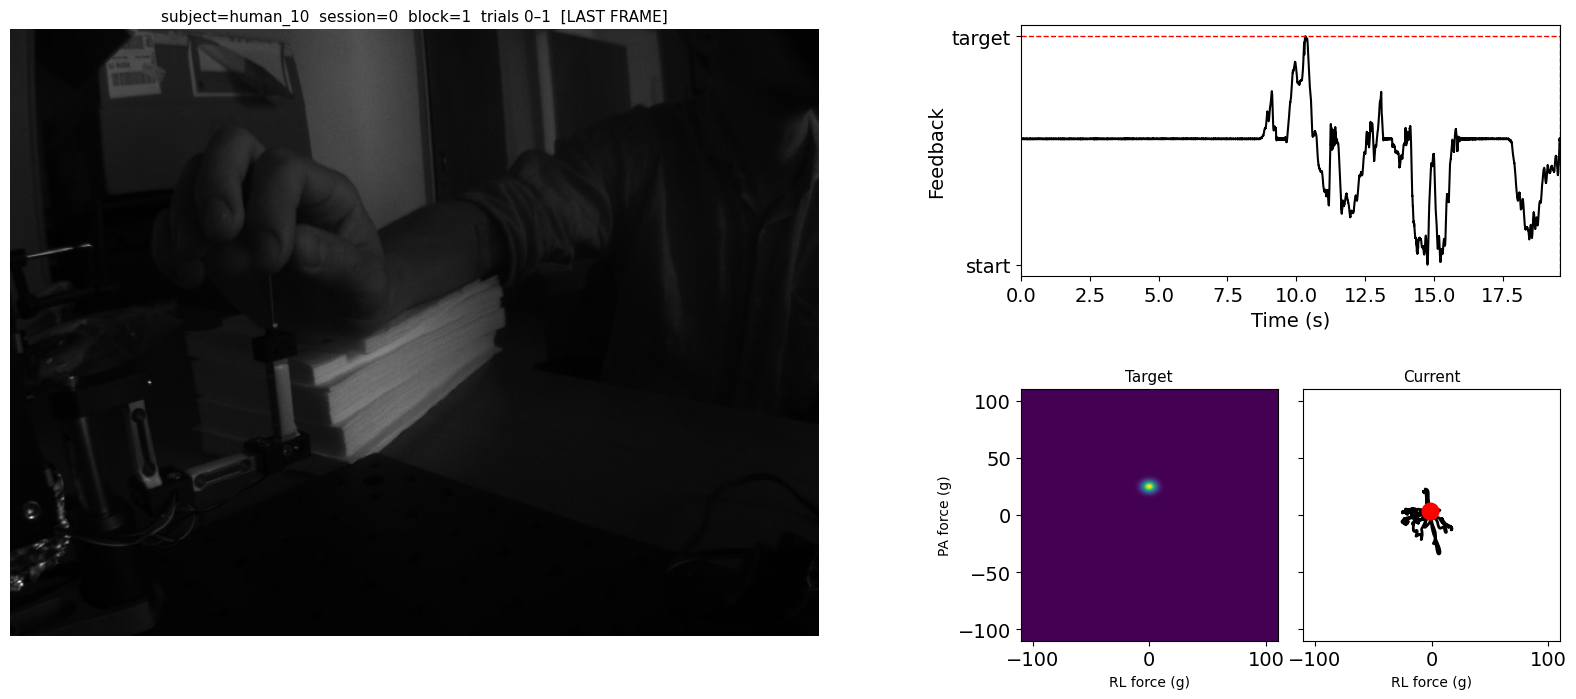

In [10]:
def _make_fig(video_frame, t_now, is_preview=False):
    fig = plt.figure(figsize=[20, 8])
    gs  = plt.GridSpec(2, 2, width_ratios=[3, 2], hspace=0.45, wspace=0.3, figure=fig)
    ax_img      = fig.add_subplot(gs[:, 0])
    ax_lickport = fig.add_subplot(gs[0, 1])
    gs_bot      = gs[1, 1].subgridspec(1, 2, wspace=0.1)
    ax_target   = fig.add_subplot(gs_bot[0])
    ax_current  = fig.add_subplot(gs_bot[1], sharex=ax_target, sharey=ax_target)

    # --- camera frame ---
    im = ax_img.imshow(video_frame)
    im.set_clim(clims)
    ax_img.axis('off')
    if is_preview:
        ax_img.set_title(f'subject={subject_id}  session={session}  block={block}  '
                         f'trials {trial_start}–{trial_end}  [LAST FRAME]', fontsize=11)

    # --- target LUT (background extends to axis limits, LUT overlaid) ---
    uniform_extent = [-force_axis_limit, force_axis_limit, -force_axis_limit, force_axis_limit]
    vmin, vmax = np.min(target_force_lut), np.max(target_force_lut)
    ax_target.imshow(np.ones(target_force_lut.shape) * vmin,
                     extent=uniform_extent, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax_target.imshow(target_force_lut, extent=lut_extent, origin='upper',
                     cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
    ax_target.set_xlim([-force_axis_limit, force_axis_limit])
    ax_target.set_ylim([-force_axis_limit, force_axis_limit])
    ax_target.set_xlabel(lbl['force_x'], fontsize=10)
    ax_target.set_ylabel(lbl['force_y'], fontsize=10)
    ax_target.set_title(lbl['lbl_target'], fontsize=11)

    # --- current force tail (shares axes with target) ---
    mask = (all_force_t >= t_now - tail_s) & (all_force_t <= t_now)
    ax_current.plot(all_force_0[mask], all_force_1[mask], 'k-', linewidth=2)
    if mask.any():
        ax_current.plot(all_force_0[mask][-1], all_force_1[mask][-1], 'ro', markersize=12)
    ax_current.set_xlabel(lbl['force_x'], fontsize=10)
    ax_current.set_title(lbl['lbl_current'], fontsize=11)
    plt.setp(ax_current.get_yticklabels(), visible=False)

    # --- feedback (normalized lickport) ---
    t_end = t_video_end if is_preview else t_now
    lp_mask = (all_lickport_t >= t_video_start) & (all_lickport_t <= t_end)
    ax_lickport.plot(all_lickport_t[lp_mask] - t_video_start, all_lickport_norm[lp_mask], 'k-')
    ax_lickport.plot([0, t_video_end - t_video_start], [1, 1], 'r--', linewidth=1)
    if all_reward_t.size:
        rew_mask = (all_reward_t >= t_video_start) & (all_reward_t <= t_end)
        ax_lickport.plot(all_reward_t[rew_mask] - t_video_start,
                         np.zeros(rew_mask.sum()) - 0.1, 'o', color='lightblue', markersize=10)
    ax_lickport.axvline(t_now - t_video_start, color='r', linestyle='--', linewidth=1)
    ax_lickport.set_xlim([0, t_video_end - t_video_start])
    ax_lickport.set_yticks([0, 1])
    ax_lickport.set_yticklabels([lbl['fb_start'], lbl['fb_target']])
    ax_lickport.set_xlabel(lbl['time'])
    ax_lickport.set_ylabel(lbl['feedback'])

    return fig

# --- preview: last frame ---
cap = cv2.VideoCapture(video_file_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, global_end_frame)
ret, last_frame = cap.read()
cap.release()

clims = np.percentile(last_frame.flatten(), [2, 98])

fig = _make_fig(last_frame, frame_session_times[-1], is_preview=True)
plt.show()

## Make video
Run the cell below to confirm and render.

In [ ]:
proceed = input('Make video? (y/n): ').strip().lower()
if proceed != 'y':
    print('Cancelled.')
else:
    cap     = cv2.VideoCapture(video_file_path)
    tmp_dir = tempfile.mkdtemp()
    try:
        n_frames = global_end_frame - global_start_frame + 1
        print(f'Rendering {n_frames} frames ...')
        for frame_i, (abs_frame, t_now) in enumerate(
                zip(range(global_start_frame, global_end_frame + 1), frame_session_times)):
            cap.set(cv2.CAP_PROP_POS_FRAMES, abs_frame)
            ret, frame = cap.read()
            if not ret:
                break
            fig = _make_fig(frame, t_now)
            plt.savefig(os.path.join(tmp_dir, f'frame_{frame_i:05d}.png'), dpi=150)
            plt.close()
            if frame_i % 50 == 0:
                print(f'  {frame_i}/{n_frames}')
        cap.release()
        print('Stitching with ffmpeg ...')
        subprocess.run([
            'ffmpeg', '-y',
            '-framerate', str(video_fps),
            '-i', os.path.join(tmp_dir, 'frame_%05d.png'),
            '-r', str(video_fps), '-pix_fmt', 'yuv420p', '-b:v', '3000k',
            output_path
        ], check=True)
        print(f'Done: {output_path}')
    finally:
        shutil.rmtree(tmp_dir)